PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING


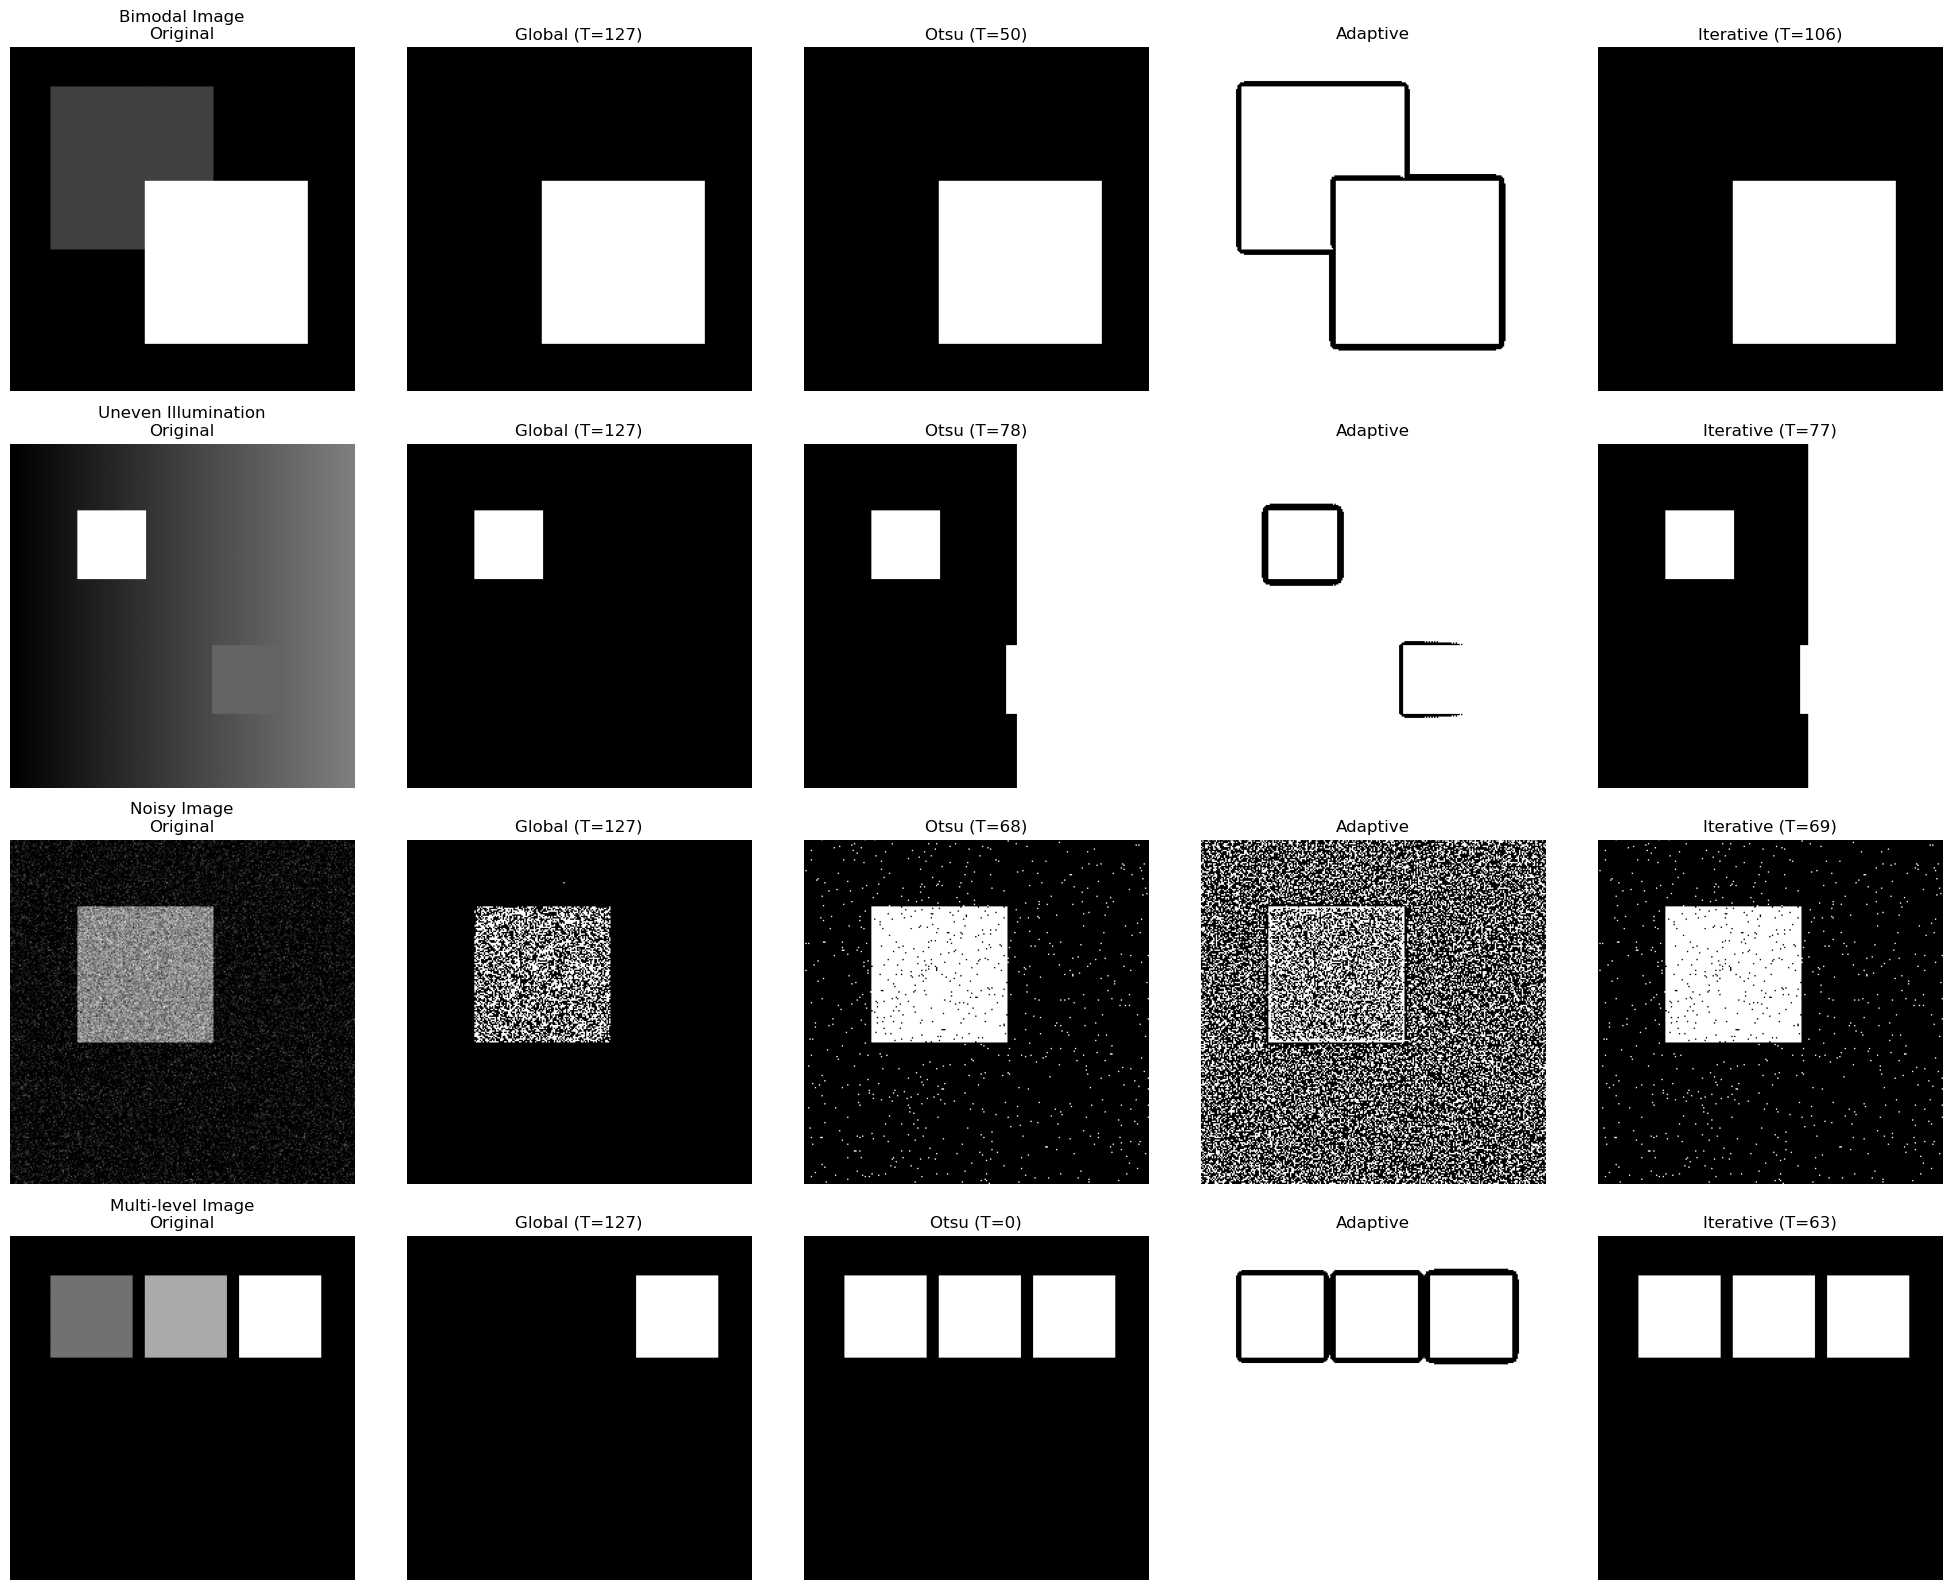


ANALISIS HISTOGRAM DAN THRESHOLD SELECTION
------------------------------------------------------------


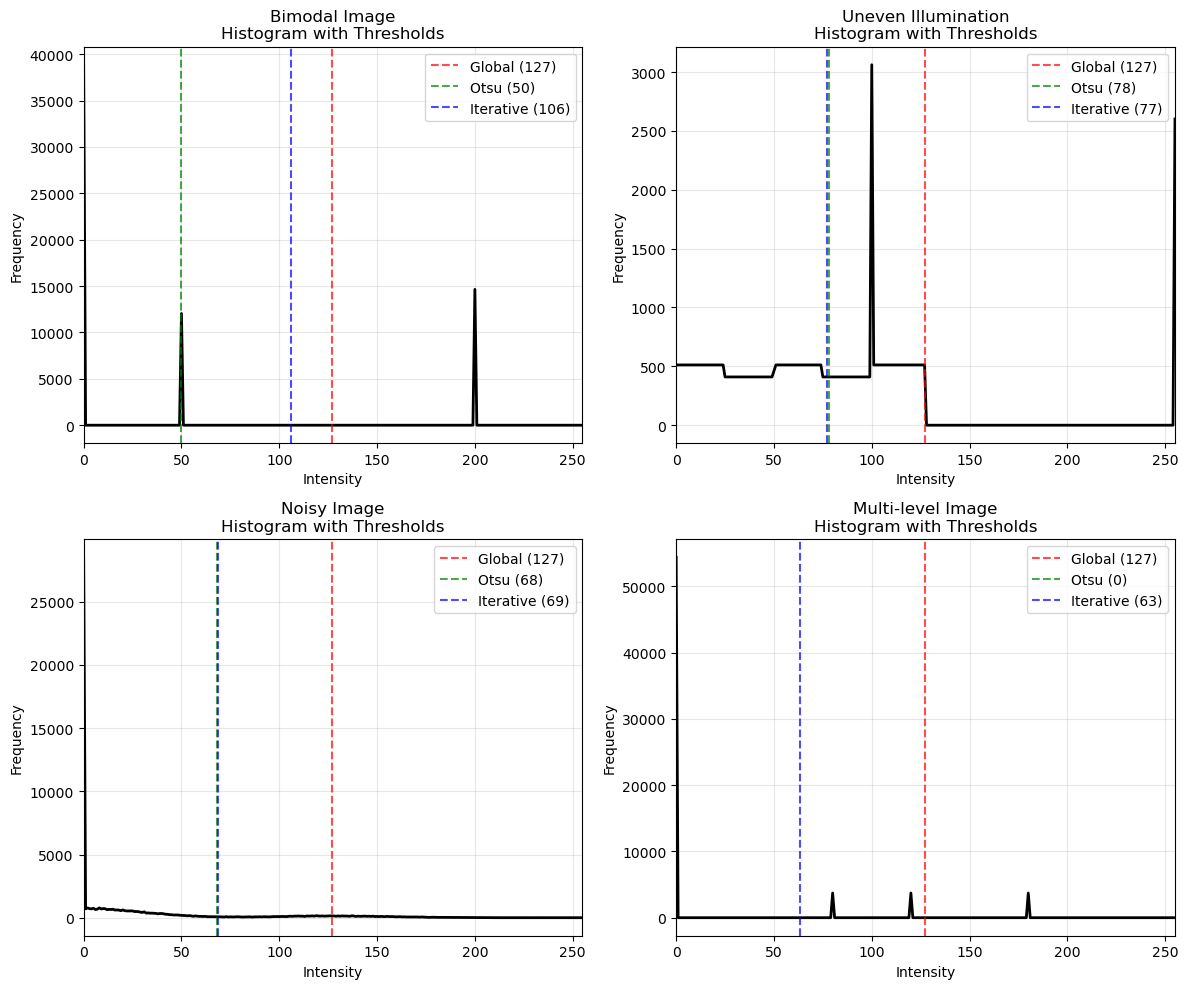


EVALUASI KUANTITATIF (DENGAN SIMULASI GROUND TRUTH)
----------------------------------------------------------------------
Method          Accuracy   Precision  Recall     F1-Score   IoU       
----------------------------------------------------------------------
Global          0.815      0.984      0.548      0.703      0.543     
Otsu            0.815      0.984      0.548      0.703      0.543     
Adaptive        0.448      0.420      0.985      0.589      0.417     
Iterative       0.815      0.984      0.548      0.703      0.543     


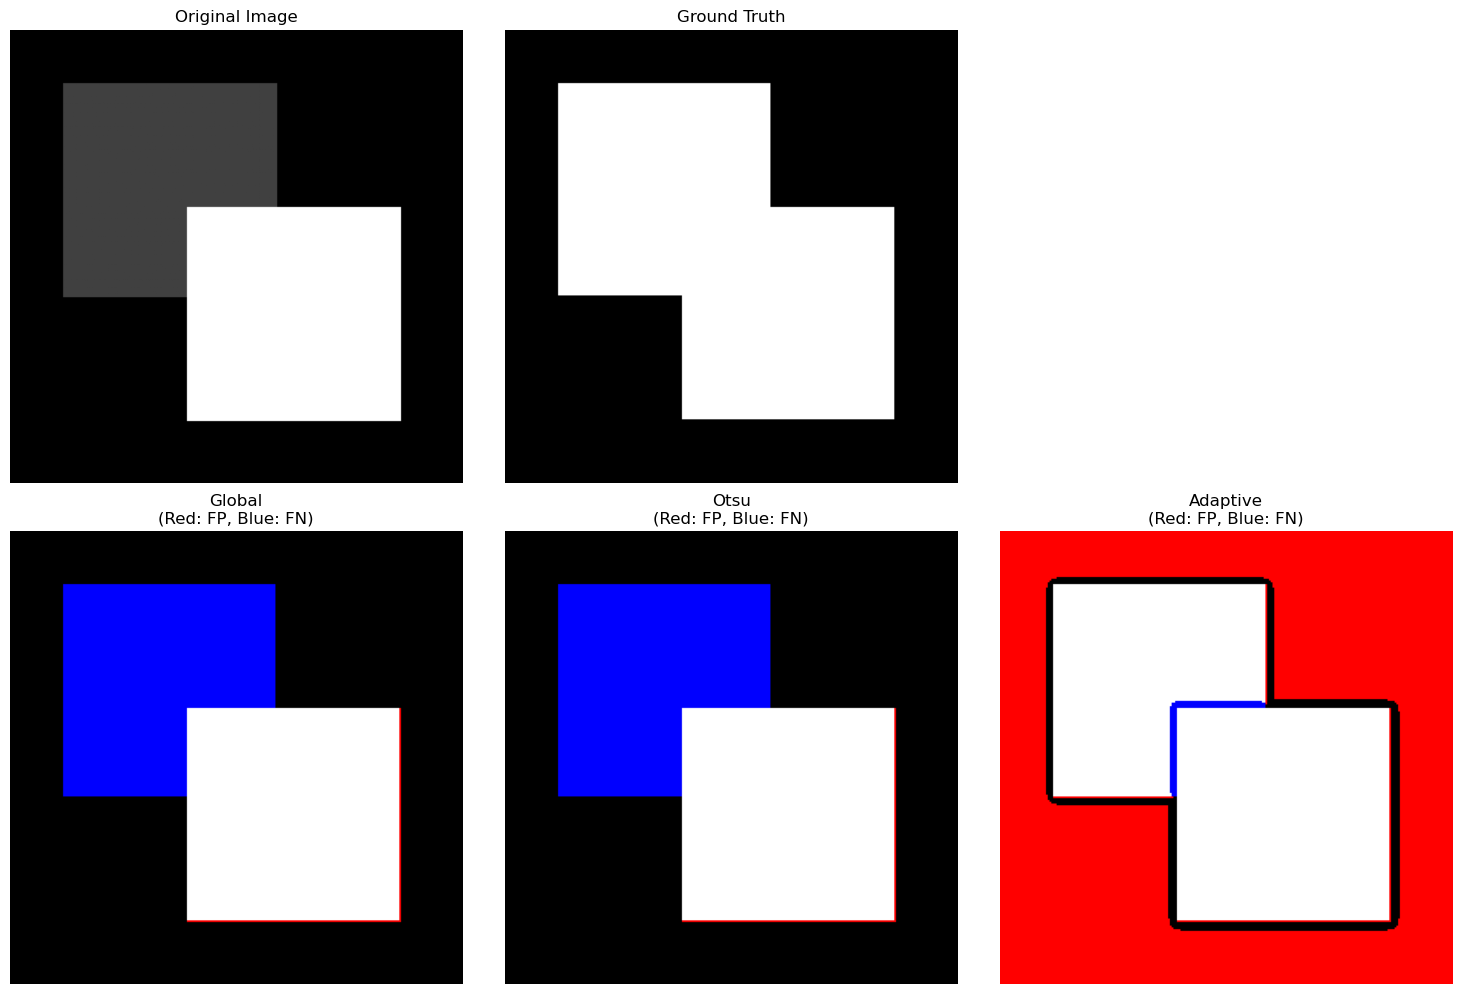


KESIMPULAN DAN REKOMENDASI
----------------------------------------

1. Global Thresholding:
   - Cocok untuk citra dengan kontras tinggi dan illumination uniform
   - Sensitif terhadap uneven illumination dan noise
   - Butuh manual threshold selection

2. Otsu's Method:
   - Fully automatic
   - Optimal untuk citra bimodal histogram
   - Tidak efektif untuk multi-modal atau uneven illumination

3. Adaptive Thresholding:
   - Cocok untuk uneven illumination
   - Robust terhadap variasi intensitas lokal
   - Parameter block size dan C perlu tuning

4. Iterative Thresholding:
   - Self-tuning threshold
   - Cocok untuk citra dengan distribusi intensity yang jelas
   - Computationally lebih expensive
    


In [2]:
# ==============================================================
# Praktikum 9.1: Thresholding Techniques Comparison
# ==============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

def praktikum_9_1():
    """
    Perbandingan teknik thresholding: Global, Otsu, dan Adaptive
    """
    print("PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING")
    print("=" * 60)
    
    # Buat citra test dengan berbagai karakteristik
    def create_test_images():
        images = {}
        
        # 1. Citra bimodal (ideal untuk thresholding)
        img_bimodal = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_bimodal, (30, 30), (150, 150), 50, -1)  # Dark object
        cv2.rectangle(img_bimodal, (100, 100), (220, 220), 200, -1)  # Bright object
        images['Bimodal Image'] = img_bimodal
        
        # 2. Citra dengan uneven illumination
        img_uneven = np.zeros((256, 256), dtype=np.uint8)
        # Create gradient background
        for i in range(256):
            img_uneven[:, i] = i // 2
        # Add objects
        cv2.rectangle(img_uneven, (50, 50), (100, 100), 255, -1)
        cv2.rectangle(img_uneven, (150, 150), (200, 200), 100, -1)
        images['Uneven Illumination'] = img_uneven
        
        # 3. Citra dengan noise
        img_noisy = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_noisy, (50, 50), (150, 150), 128, -1)
        # Add Gaussian noise
        noise = np.random.normal(0, 30, img_noisy.shape)
        img_noisy = np.clip(img_noisy.astype(float) + noise, 0, 255).astype(np.uint8)
        images['Noisy Image'] = img_noisy
        
        # 4. Citra dengan multiple intensity levels
        img_multi = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_multi, (30, 30), (90, 90), 80, -1)   # Dark gray
        cv2.rectangle(img_multi, (100, 30), (160, 90), 120, -1)  # Medium gray
        cv2.rectangle(img_multi, (170, 30), (230, 90), 180, -1)  # Light gray
        images['Multi-level Image'] = img_multi
        
        return images
    
    # Implementasi berbagai metode thresholding
    def apply_global_threshold(image, T=127):
        """Global thresholding"""
        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary
    
    def apply_otsu_threshold(image):
        """Otsu's thresholding"""
        _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary
    
    def apply_adaptive_threshold(image, block_size=11, C=2):
        """Adaptive thresholding"""
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, block_size, C)
        return binary
    
    def apply_iterative_threshold(image, max_iter=100, tolerance=1):
        """Iterative threshold selection"""
        # Initialize threshold
        T = np.mean(image)
        
        for i in range(max_iter):
            # Segment image
            foreground = image[image > T]
            background = image[image <= T]
            
            # Compute means
            if len(foreground) > 0 and len(background) > 0:
                mu_fg = np.mean(foreground)
                mu_bg = np.mean(background)
                
                # New threshold
                T_new = (mu_fg + mu_bg) / 2
                
                # Check convergence
                if abs(T_new - T) < tolerance:
                    T = T_new
                    break
                    
                T = T_new
            else:
                break
        
        # Apply threshold
        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary, T
    
    # Buat citra test
    test_images = create_test_images()
    
    # Terapkan berbagai metode thresholding
    results = {}
    
    for name, image in test_images.items():
        # Convert to grayscale if needed
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        
        # Apply different thresholding methods
        global_binary = apply_global_threshold(gray, 127)
        otsu_binary = apply_otsu_threshold(gray)
        adaptive_binary = apply_adaptive_threshold(gray, 11, 2)
        iterative_binary, T_iter = apply_iterative_threshold(gray)
        
        # Get Otsu threshold value
        T_otsu, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        results[name] = {
            'original': gray,
            'global': global_binary,
            'otsu': otsu_binary,
            'adaptive': adaptive_binary,
            'iterative': iterative_binary,
            'T_otsu': T_otsu,
            'T_iter': T_iter[1] if isinstance(T_iter, tuple) else T_iter
        }
    
    # Visualisasi hasil
    fig, axes = plt.subplots(len(test_images), 5, figsize=(20, 4*len(test_images)))
    
    for idx, (name, result) in enumerate(results.items()):
        # Column 1: Original image + histogram
        axes[idx, 0].imshow(result['original'], cmap='gray')
        axes[idx, 0].set_title(f'{name}\nOriginal')
        axes[idx, 0].axis('off')
        
        # Column 2-5: Thresholding results
        methods = ['global', 'otsu', 'adaptive', 'iterative']
        titles = ['Global (T=127)', f'Otsu (T={result["T_otsu"]:.0f})', 
                 'Adaptive', f'Iterative (T={result["T_iter"]:.0f})']
        
        for col, (method, title) in enumerate(zip(methods, titles), 1):
            axes[idx, col].imshow(result[method], cmap='gray')
            axes[idx, col].set_title(title)
            axes[idx, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Analisis histogram dan threshold selection
    print("\nANALISIS HISTOGRAM DAN THRESHOLD SELECTION")
    print("-" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    
    for idx, (name, result) in enumerate(list(results.items())[:4]):
        # Plot histogram
        hist = cv2.calcHist([result['original']], [0], None, [256], [0, 256])
        axes[idx].plot(hist, 'k-', linewidth=2)
        
        # Add threshold lines
        axes[idx].axvline(x=127, color='r', linestyle='--', label='Global (127)', alpha=0.7)
        axes[idx].axvline(x=result['T_otsu'], color='g', linestyle='--', 
                         label=f'Otsu ({result["T_otsu"]:.0f})', alpha=0.7)
        axes[idx].axvline(x=result['T_iter'], color='b', linestyle='--',
                         label=f'Iterative ({result["T_iter"]:.0f})', alpha=0.7)
        
        axes[idx].set_title(f'{name}\nHistogram with Thresholds')
        axes[idx].set_xlabel('Intensity')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim([0, 255])
    
    plt.tight_layout()
    plt.show()
    
    # Evaluasi kuantitatif (simulasi ground truth)
    print("\nEVALUASI KUANTITATIF (DENGAN SIMULASI GROUND TRUTH)")
    print("-" * 70)
    
    # Buat ground truth untuk bimodal image
    gt_bimodal = np.zeros((256, 256), dtype=np.uint8)
    gt_bimodal[30:150, 30:150] = 1  # First object
    gt_bimodal[100:220, 100:220] = 1  # Second object
    
    # Hitung metrics untuk setiap metode
    def calculate_metrics(binary, ground_truth):
        """Calculate segmentation metrics"""
        # Ensure binary images
        binary = (binary > 0).astype(np.uint8)
        ground_truth = (ground_truth > 0).astype(np.uint8)
        
        # True Positive, False Positive, etc.
        tp = np.sum((binary == 1) & (ground_truth == 1))
        fp = np.sum((binary == 1) & (ground_truth == 0))
        fn = np.sum((binary == 0) & (ground_truth == 1))
        tn = np.sum((binary == 0) & (ground_truth == 0))
        
        # Calculate metrics
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
            'iou': iou
        }
    
    # Evaluasi untuk bimodal image
    bimodal_result = results['Bimodal Image']
    
    print(f"{'Method':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'IoU':<10}")
    print("-" * 70)
    
    methods = ['global', 'otsu', 'adaptive', 'iterative']
    method_names = ['Global', 'Otsu', 'Adaptive', 'Iterative']
    
    for method, method_name in zip(methods, method_names):
        metrics = calculate_metrics(bimodal_result[method], gt_bimodal)
        print(f"{method_name:<15} {metrics['accuracy']:<10.3f} {metrics['precision']:<10.3f} "
              f"{metrics['recall']:<10.3f} {metrics['f1_score']:<10.3f} {metrics['iou']:<10.3f}")
    
    # Visual comparison dengan ground truth
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Original and ground truth
    axes[0, 0].imshow(bimodal_result['original'], cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gt_bimodal, cmap='gray')
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')
    
    axes[0, 2].axis('off')  # Empty
    
    # Row 2: Thresholding results dengan overlay errors
    for idx, (method, method_name) in enumerate(zip(methods[:3], method_names[:3])):
        result_binary = (bimodal_result[method] > 0).astype(np.uint8)
        
        # Create error visualization
        error_image = np.zeros((256, 256, 3), dtype=np.uint8)
        
        # True Positive: White
        tp_mask = (result_binary == 1) & (gt_bimodal == 1)
        error_image[tp_mask] = [255, 255, 255]
        
        # False Positive: Red (segmented but not in GT)
        fp_mask = (result_binary == 1) & (gt_bimodal == 0)
        error_image[fp_mask] = [255, 0, 0]
        
        # False Negative: Blue (in GT but not segmented)
        fn_mask = (result_binary == 0) & (gt_bimodal == 1)
        error_image[fn_mask] = [0, 0, 255]
        
        axes[1, idx].imshow(error_image)
        axes[1, idx].set_title(f'{method_name}\n(Red: FP, Blue: FN)')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Kesimpulan dan rekomendasi
    print("\nKESIMPULAN DAN REKOMENDASI")
    print("-" * 40)
    print("""
1. Global Thresholding:
   - Cocok untuk citra dengan kontras tinggi dan illumination uniform
   - Sensitif terhadap uneven illumination dan noise
   - Butuh manual threshold selection

2. Otsu's Method:
   - Fully automatic
   - Optimal untuk citra bimodal histogram
   - Tidak efektif untuk multi-modal atau uneven illumination

3. Adaptive Thresholding:
   - Cocok untuk uneven illumination
   - Robust terhadap variasi intensitas lokal
   - Parameter block size dan C perlu tuning

4. Iterative Thresholding:
   - Self-tuning threshold
   - Cocok untuk citra dengan distribusi intensity yang jelas
   - Computationally lebih expensive
    """)
    
    return results

thresholding_results = praktikum_9_1()


PRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION

EDGE DETECTION RESULTS
----------------------------------------


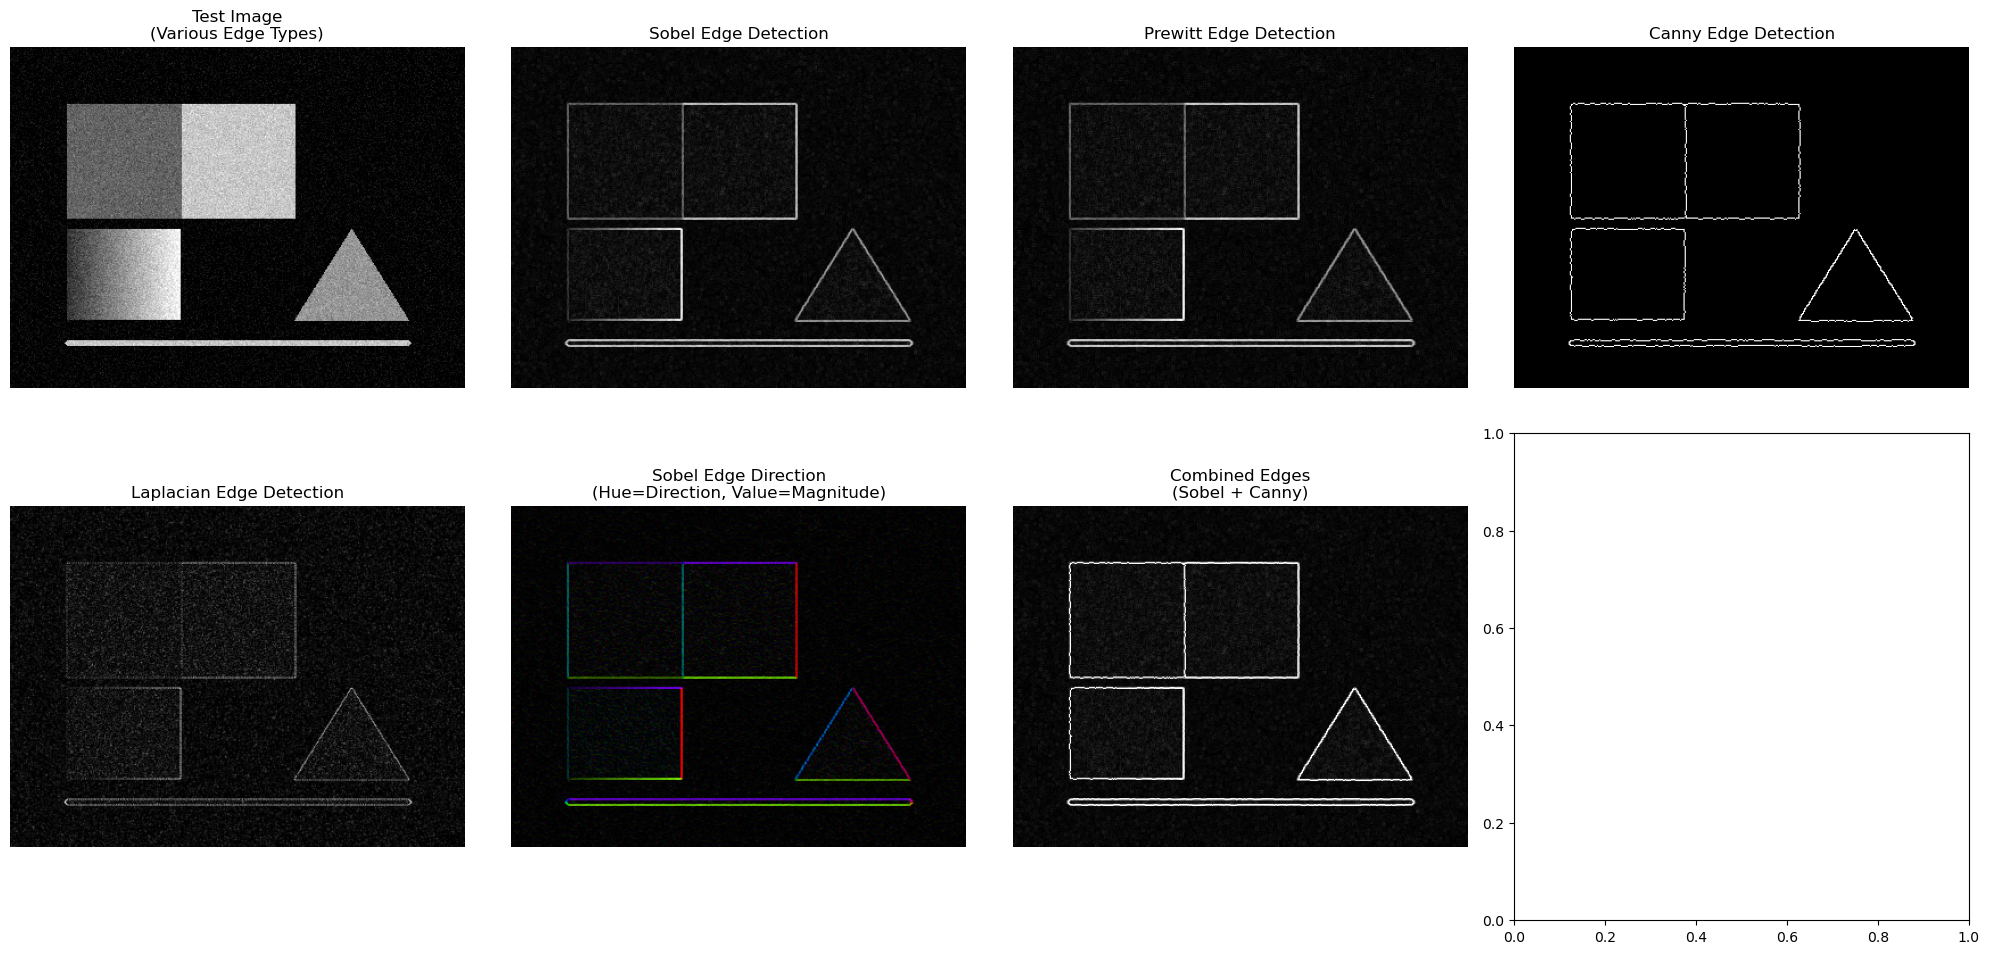


EDGE DETECTOR COMPARISON ANALYSIS
--------------------------------------------------
Method          Density    Components   Avg Size     Thinness  
------------------------------------------------------------
Sobel           0.0212     15           169.47       53.00     
Prewitt         0.0216     15           172.60       67.77     
Canny           0.0169     4            506.00       7.14      
Laplacian       0.0006     45           1.56         6.60      

REGION-BASED SEGMENTATION RESULTS
--------------------------------------------------


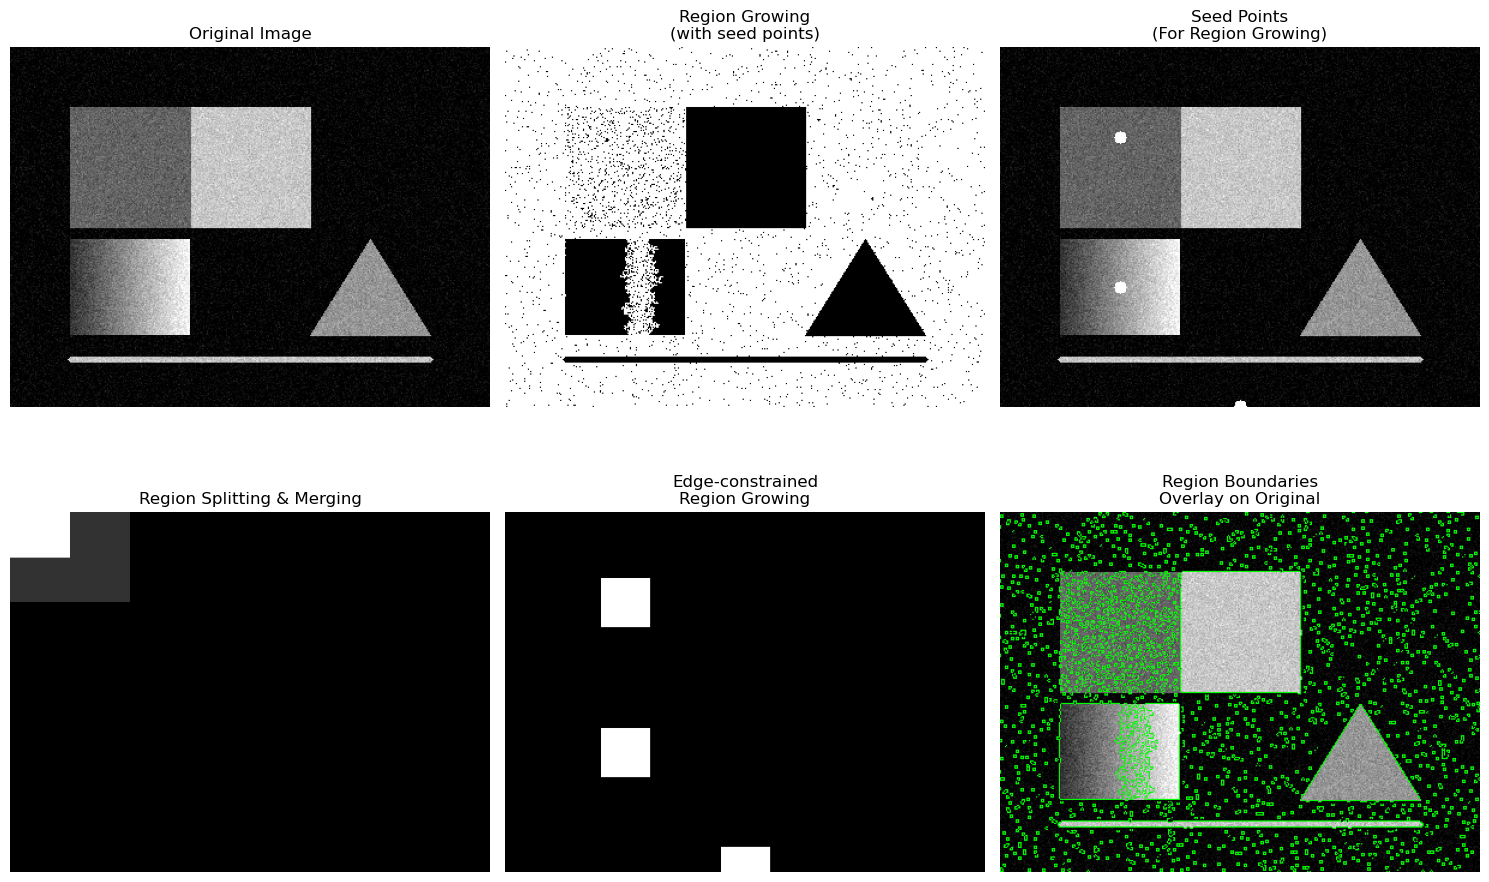


REGION CHARACTERISTICS ANALYSIS
--------------------------------------------------
Number of regions detected: 1

Region Statistics:
Region   Area       Mean       Std        Centroid            
------------------------------------------------------------
1        95272      17.08      35.43      (202.7, 147.3)      


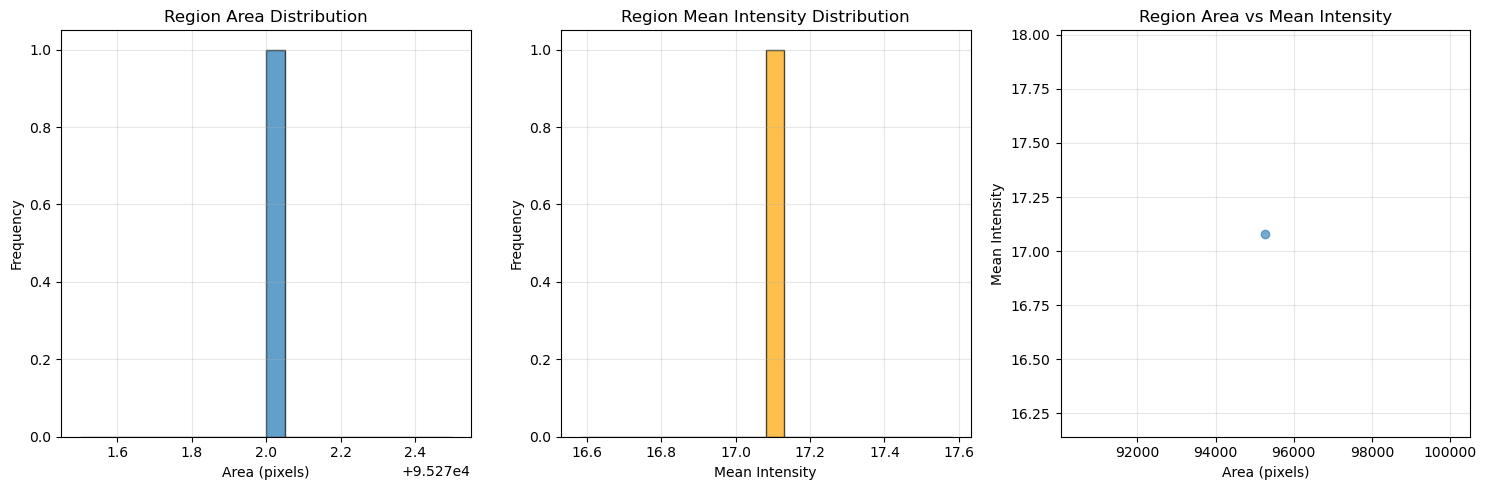


KESIMPULAN DAN APLIKASI PRAKTIS
----------------------------------------

1. Edge Detection:
   - Sobel/Prewitt: Baik untuk gradient magnitude, sensitif noise
   - Canny: Robust dengan noise reduction, menghasilkan thin edges
   - Laplacian: Deteksi zero-crossing, sensitif terhadap noise

2. Region-based Methods:
   - Region Growing: Intuitif butuh seed points, sensitive to parameters
   - Split & Merge: Fully automatic, cocok untuk regular structures
   - Hybrid approaches: Kombinasi edge dan region information

3. Aplikasi Praktis:
   - Medical imaging: Organ segmentation
   - Remote sensing: Land cover classification
   - Industrial inspection: Defect detection
   - Document analysis: Text region extraction
    


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

# ==============================================================
# Praktikum 9.2: Edge Detection dan Region-based Segmentation
# ==============================================================

def praktikum_9_2():
    """
    Implementasi edge detection dan region-based segmentation
    """
    print("\nPRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION")
    print("=" * 70)

    # Buat citra test dengan berbagai edge types
    def create_edge_test_image():
        """Create test image with different edge types"""
        img = np.zeros((300, 400), dtype=np.uint8)

        # Step edge (sharp transition)
        cv2.rectangle(img, (50, 50), (150, 150), 100, -1)
        cv2.rectangle(img, (151, 50), (250, 150), 200, -1)

        # Ramp edge (gradual transition)
        for i in range(50, 150):
            img[160:240, i] = 50 + (i - 50) * 2

        # Roof edge (triangular)
        triangle_cnt = np.array([(300, 160), (350, 240), (250, 240)])
        cv2.drawContours(img, [triangle_cnt], 0, 150, -1)

        # Line edge (thin line)
        cv2.line(img, (50, 260), (350, 260), 200, 3)

        # Add noise untuk testing robustness
        noise = np.random.normal(0, 15, img.shape)
        img = np.clip(img.astype(float) + noise, 0, 255).astype(np.uint8)

        return img

    # Implementasi berbagai edge detectors
    def apply_sobel_edge_detection(image, ksize=3):
        """Sobel edge detection"""
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)

        # Compute magnitude
        magnitude = np.sqrt(sobelx**2 + sobely**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

        # Compute direction
        direction = np.arctan2(sobely, sobelx) * 180 / np.pi

        return magnitude.astype(np.uint8), direction

    def apply_prewitt_edge_detection(image):
        """Prewitt edge detection"""
        # Define Prewitt kernels
        kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
        kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

        prewittx = cv2.filter2D(image.astype(np.float64), -1, kernelx)
        prewitty = cv2.filter2D(image.astype(np.float64), -1, kernely)

        # Compute magnitude
        magnitude = np.sqrt(prewittx**2 + prewitty**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

        return magnitude.astype(np.uint8)

    def apply_canny_edge_detection(image, low_threshold=50, high_threshold=150):
        """Canny edge detection"""
        # Apply Gaussian blur
        blurred = cv2.GaussianBlur(image, (5, 5), 1.4)

        # Apply Canny
        edges = cv2.Canny(blurred, low_threshold, high_threshold)

        return edges

    def apply_laplacian_edge_detection(image):
        """Laplacian edge detection"""
        laplacian = cv2.Laplacian(image, cv2.CV_64F)
        laplacian = np.abs(laplacian)
        laplacian = cv2.normalize(laplacian, None, 0, 255, cv2.NORM_MINMAX)

        return laplacian.astype(np.uint8)

    # Region-based segmentation methods
    def region_growing_segmentation(image, seeds, threshold=20):
        """Region growing segmentation"""
        segmented = np.zeros_like(image)
        visited = np.zeros_like(image, dtype=bool)

        # Convert seeds to list if single seed
        if isinstance(seeds, tuple):
            seeds = [seeds]

        for seed in seeds:
            if visited[seed]:
                continue

            stack = [seed]
            region_pixels = []

            while stack:
                x, y = stack.pop()

                if visited[x, y]:
                    continue

                visited[x, y] = True
                current_value = image[x, y]
                region_pixels.append(current_value)
                segmented[x, y] = 255

                # Check 4-connected neighbors
                neighbors = [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]
                region_mean = np.mean(region_pixels)

                for nx, ny in neighbors:
                    if (0 <= nx < image.shape[0] and 0 <= ny < image.shape[1]
                        and not visited[nx, ny]):
                        neighbor_value = image[nx, ny]
                        if abs(neighbor_value - region_mean) < threshold:
                            stack.append((nx, ny))

        return segmented

    def region_splitting_merging(image, min_size=32, threshold=20):
        """Region splitting and merging algorithm"""
        def should_split(region):
            """Check if region should be split"""
            return np.std(region) > threshold and region.shape[0] > min_size

        def split_region(region):
            """Split region into 4 sub-regions"""
            h, w = region.shape
            return [
                region[:h//2, :w//2],  # Top-left
                region[:h//2, w//2:],  # Top-right
                region[h//2:, :w//2],  # Bottom-left
                region[h//2:, w//2:]   # Bottom-right
            ]

        def merge_regions(regions):
            """Merge similar adjacent regions"""
            # This is a simplified implementation
            # In practice, you would check adjacency and similarity
            merged = []
            used = [False] * len(regions)

            for i, region in enumerate(regions):
                if used[i]:
                    continue

                current_region = region
                used[i] = True

                # Try to merge with similar regions
                for j, other_region in enumerate(regions[i+1:], i+1):
                    if used[j]:
                        continue

                    # Check similarity (simplified)
                    if (abs(np.mean(current_region) - np.mean(other_region)) < threshold and
                        abs(np.std(current_region) - np.std(other_region)) < threshold/2):

                        # Merge regions (simplified - just combine)
                        h1, w1 = current_region.shape
                        h2, w2 = other_region.shape
                        h_max = max(h1, h2)
                        w_max = max(w1, w2)

                        merged_region = np.zeros((h_max, w_max))
                        merged_region[:h1, :w1] = current_region
                        merged_region[:h2, :w2] = np.maximum(
                            merged_region[:h2, :w2], other_region
                        )

                        current_region = merged_region
                        used[j] = True

                merged.append(current_region)

            return merged

        # Start with whole image
        regions = [image]

        # Split phase
        splitting = True
        while splitting:
            splitting = False
            new_regions = []

            for region in regions:
                if should_split(region):
                    new_regions.extend(split_region(region))
                    splitting = True
                else:
                    new_regions.append(region)

            regions = new_regions

        # Merge phase
        regions = merge_regions(regions)

        # Create visualization
        result = np.zeros_like(image)
        current_value = 50

        for region in regions:
            h, w = region.shape
            result[:h, :w] = current_value
            current_value = min(current_value + 50, 255)

        return result

    # Buat citra test
    test_image = create_edge_test_image()

    # Terapkan berbagai edge detectors
    edge_results = {}

    # Sobel
    sobel_magnitude, sobel_direction = apply_sobel_edge_detection(test_image)
    edge_results['Sobel'] = sobel_magnitude

    # Prewitt
    prewitt_magnitude = apply_prewitt_edge_detection(test_image)
    edge_results['Prewitt'] = prewitt_magnitude

    # Canny
    canny_edges = apply_canny_edge_detection(test_image)
    edge_results['Canny'] = canny_edges

    # Laplacian
    laplacian_edges = apply_laplacian_edge_detection(test_image)
    edge_results['Laplacian'] = laplacian_edges

    # Region-based segmentation
    region_results = {}

    # Region growing dengan berbagai seeds
    seeds = [(75, 100),  # Step edge region
             (200, 100), # Ramp edge region
             (299, 200)] # Roof edge region

    region_grown = region_growing_segmentation(test_image, seeds, threshold=25)
    region_results['Region Growing'] = region_grown

    # Region splitting and merging
    split_merge_result = region_splitting_merging(test_image, min_size=32, threshold=20)
    region_results['Split & Merge'] = split_merge_result

    # Visualisasi hasil edge detection
    print("\nEDGE DETECTION RESULTS")
    print("-" * 40)

    # FIX: Changed subplot dimensions from (2, 3) to (2, 4) to accommodate all plots in the first row.
    # FIX: Changed enumerate start index from 1 to 0 and adjusted indexing for `axes` accordingly.
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    # Row 1: Original and edge detectors
    axes[0, 0].imshow(test_image, cmap='gray')
    axes[0, 0].set_title('Test Image\n(Various Edge Types)')
    axes[0, 0].axis('off')

    methods = ['Sobel', 'Prewitt', 'Canny']
    for idx, method in enumerate(methods, 0):
        axes[0, idx+1].imshow(edge_results[method], cmap='gray')
        axes[0, idx+1].set_title(f'{method} Edge Detection')
        axes[0, idx+1].axis('off')

    # Row 2: More edge detectors and edge direction
    axes[1, 0].imshow(edge_results['Laplacian'], cmap='gray')
    axes[1, 0].set_title('Laplacian Edge Detection')
    axes[1, 0].axis('off')

    # Sobel direction (as HSV image)
    hsv = np.zeros((test_image.shape[0], test_image.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = (sobel_direction + 180) / 2  # Hue based on direction
    hsv[..., 1] = 255  # Full saturation
    hsv[..., 2] = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX)
    axes[1, 1].imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
    axes[1, 1].set_title('Sobel Edge Direction\n(Hue=Direction, Value=Magnitude)')
    axes[1, 1].axis('off')

    # Combined edges visualization
    combined_edges = np.zeros_like(test_image)
    for method in ['Sobel', 'Canny']:
        edges_norm = edge_results[method] / 255.0
        combined_edges = np.maximum(combined_edges, edges_norm * 255)

    axes[1, 2].imshow(combined_edges, cmap='gray')
    axes[1, 2].set_title('Combined Edges\n(Sobel + Canny)')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # Analisis komparatif edge detectors
    print("\nEDGE DETECTOR COMPARISON ANALYSIS")
    print("-" * 50)

    # Hitung edge density dan continuity
    def analyze_edge_image(edge_image, threshold=128):
        """Analyze edge image characteristics"""
        binary_edges = (edge_image > threshold).astype(np.uint8)

        # Edge density
        edge_density = np.sum(binary_edges) / binary_edges.size

        # Edge continuity (using connected components)
        num_labels, labels = cv2.connectedComponents(binary_edges)
        avg_component_size = np.sum(binary_edges) / max(num_labels - 1, 1)

        # Thinness ratio (perimeter^2 / area)
        contours, _ = cv2.findContours(binary_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        thinness_ratios = []

        for contour in contours:
            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True)
            if area > 0:
                thinness = perimeter**2 / (4 * np.pi * area)
                thinness_ratios.append(thinness)

        avg_thinness = np.mean(thinness_ratios) if thinness_ratios else 0

        return {
            'density': edge_density,
            'num_components': num_labels - 1,
            'avg_component_size': avg_component_size,
            'avg_thinness': avg_thinness
        }

    print(f"{'Method':<15} {'Density':<10} {'Components':<12} {'Avg Size':<12} {'Thinness':<10}")
    print("-" * 60)

    for method_name, edge_image in edge_results.items():
        analysis = analyze_edge_image(edge_image)
        print(f"{method_name:<15} {analysis['density']:<10.4f} {analysis['num_components']:<12} "
              f"{analysis['avg_component_size']:<12.2f} {analysis['avg_thinness']:<10.2f}")

    # Visualisasi region-based segmentation
    print("\nREGION-BASED SEGMENTATION RESULTS")
    print("-" * 50)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Row 1: Original and region growing
    axes[0, 0].imshow(test_image, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(region_results['Region Growing'], cmap='gray')
    axes[0, 1].set_title('Region Growing\n(with seed points)')
    axes[0, 1].axis('off')

    # Tampilkan seed points
    seed_display = test_image.copy()
    for seed in seeds:
        cv2.circle(seed_display, (seed[1], seed[0]), 5, 255, -1)
    axes[0, 2].imshow(seed_display, cmap='gray')
    axes[0, 2].set_title('Seed Points\n(For Region Growing)')
    axes[0, 2].axis('off')

    # Row 2: Split & merge dan hybrid approach
    axes[1, 0].imshow(region_results['Split & Merge'], cmap='gray')
    axes[1, 0].set_title('Region Splitting & Merging')
    axes[1, 0].axis('off')

    # Hybrid approach: Edge-based + Region-based
    # Gunakan edges sebagai constraint untuk region growing
    edge_constrained = canny_edges.copy()
    edge_constrained = cv2.dilate(edge_constrained, np.ones((3,3), np.uint8), iterations=1)

    # Region growing dengan edge constraints
    constrained_result = np.zeros_like(test_image)
    for seed in seeds:
        # Simple constrained region growing
        mask = np.zeros_like(test_image, dtype=np.uint8)
        mask[seed] = 1

        # Dilate mask but stop at edges
        for _ in range(20):
            dilated = cv2.dilate(mask, np.ones((3,3), np.uint8))
            # Stop dilation at edges
            dilated[edge_constrained > 0] = 0
            if np.array_equal(dilated, mask):
                break
            mask = dilated

        constrained_result[mask > 0] = 255

    axes[1, 1].imshow(constrained_result, cmap='gray')
    axes[1, 1].set_title('Edge-constrained\nRegion Growing')
    axes[1, 1].axis('off')

    # Region boundaries overlay
    boundaries = cv2.Canny(region_results['Region Growing'].astype(np.uint8), 50, 150)
    overlay = cv2.cvtColor(test_image, cv2.COLOR_GRAY2BGR)
    overlay[boundaries > 0] = [0, 255, 0]

    axes[1, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('Region Boundaries\nOverlay on Original')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # Analisis region characteristics
    print("\nREGION CHARACTERISTICS ANALYSIS")
    print("-" * 50)

    def analyze_regions(binary_image):
        """Analyze segmented regions"""
        # Label connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_image, connectivity=8
        )

        region_info = []
        for i in range(1, num_labels):  # Skip background (label 0)
            area = stats[i, cv2.CC_STAT_AREA]
            left = stats[i, cv2.CC_STAT_LEFT]
            top = stats[i, cv2.CC_STAT_TOP]
            width = stats[i, cv2.CC_STAT_WIDTH]
            height = stats[i, cv2.CC_STAT_HEIGHT]

            # Extract region pixels
            region_mask = (labels == i)
            region_pixels = test_image[region_mask]

            region_info.append({
                'label': i,
                'area': area,
                'centroid': centroids[i],
                'mean_intensity': np.mean(region_pixels),
                'std_intensity': np.std(region_pixels),
                'bbox': (left, top, width, height)
            })

        return region_info

    # Analisis region growing results
    region_grown_binary = (region_results['Region Growing'] > 0).astype(np.uint8)
    region_info = analyze_regions(region_grown_binary)

    print(f"Number of regions detected: {len(region_info)}")
    print("\nRegion Statistics:")
    print(f"{'Region':<8} {'Area':<10} {'Mean':<10} {'Std':<10} {'Centroid':<20}")
    print("-" * 60)

    for info in region_info[:5]:  # Show first 5 regions
        centroid_str = f"({info['centroid'][0]:.1f}, {info['centroid'][1]:.1f})";
        print(f"{info['label']:<8} {info['area']:<10} {info['mean_intensity']:<10.2f} "
              f"{info['std_intensity']:<10.2f} {centroid_str:<20}")

    # Visualisasi region properties
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Region area distribution
    areas = [info['area'] for info in region_info]
    axes[0].hist(areas, bins=20, alpha=0.7, edgecolor='black')
    axes[0].set_title('Region Area Distribution')
    axes[0].set_xlabel('Area (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

    # Region intensity distribution
    intensities = [info['mean_intensity'] for info in region_info]
    axes[1].hist(intensities, bins=20, alpha=0.7, edgecolor='black', color='orange')
    axes[1].set_title('Region Mean Intensity Distribution')
    axes[1].set_xlabel('Mean Intensity')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

    # Scatter plot: Area vs Intensity
    axes[2].scatter(areas, intensities, alpha=0.6)
    axes[2].set_title('Region Area vs Mean Intensity')
    axes[2].set_xlabel('Area (pixels)')
    axes[2].set_ylabel('Mean Intensity')
    axes[2].grid(True, alpha=0.3)

    # Add regression line
    if len(areas) > 1:
        z = np.polyfit(areas, intensities, 1)
        p = np.poly1d(z)
        axes[2].plot(areas, p(areas), "r--", alpha=0.8,
                    label=f'Correlation: {np.corrcoef(areas, intensities)[0,1]:.2f}')
        axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Kesimpulan dan aplikasi praktis
    print("\nKESIMPULAN DAN APLIKASI PRAKTIS")
    print("-" * 40)
    print("""
1. Edge Detection:
   - Sobel/Prewitt: Baik untuk gradient magnitude, sensitif noise
   - Canny: Robust dengan noise reduction, menghasilkan thin edges
   - Laplacian: Deteksi zero-crossing, sensitif terhadap noise

2. Region-based Methods:
   - Region Growing: Intuitif butuh seed points, sensitive to parameters
   - Split & Merge: Fully automatic, cocok untuk regular structures
   - Hybrid approaches: Kombinasi edge dan region information

3. Aplikasi Praktis:
   - Medical imaging: Organ segmentation
   - Remote sensing: Land cover classification
   - Industrial inspection: Defect detection
   - Document analysis: Text region extraction
    """)

    return test_image, edge_results, region_results

edge_test_image, edge_results, region_results = praktikum_9_2()